# Factor-level enrichment (Factor_ER)

Complementary to the edge-level curveball permutation enrichment (`Representation_ERs`). This notebook tests, per GWAS-colocalized factor `(Source_module, Source_gene, program)`, whether presence of each annotation resource (and TF-cascade) differs between `Within-only`, `Across-only`, and `Mixed` factors - motivated by the observation that Ligand-Receptor relationships should be structurally more associated with Across/Mixed factors than Within-only ones.

# Load libraries

In [1]:
suppressMessages(library("data.table"))
suppressMessages(library("withr"))
suppressMessages(library("ggplot2"))
suppressMessages(library("farver"))
suppressMessages(library("labeling"))
suppressMessages(library("optparse"))
suppressMessages(library("dplyr"))
suppressMessages(library("withr"))
suppressMessages(library("backports"))
suppressMessages(library("broom"))
suppressMessages(library("rstudioapi"))
suppressMessages(library("tzdb"))
suppressMessages(library("svglite"))
suppressMessages(library("ggeasy"))
suppressMessages(library("tidyverse"))
suppressMessages(library("BiocGenerics"))
suppressMessages(library("S4Vectors"))
suppressMessages(library("IRanges"))
suppressMessages(library("GenomeInfoDb"))
suppressMessages(library("GenomicRanges"))
suppressMessages(library("Biobase"))
suppressMessages(library("AnnotationDbi"))
suppressMessages(library("GO.db"))
suppressMessages(library("org.Hs.eg.db"))
suppressMessages(library("ggrepel"))
suppressMessages(library("RColorBrewer"))
suppressMessages(library("svglite"))
suppressMessages(library("cowplot"))
suppressMessages(library("Matrix"))
suppressMessages(library("rtracklayer"))
suppressMessages(library("Biostrings"))
suppressMessages(library("ggrepel"))
suppressMessages(library("ggnewscale"))
suppressMessages(library("splitstackshape"))
suppressMessages(library("viridis"))
suppressMessages(library("ggsci"))
suppressMessages(library("plyr"))
suppressMessages(library("ggupset"))
suppressMessages(library("patchwork"))
suppressMessages(library("ggh4x"))
suppressMessages(library("ComplexHeatmap"))
suppressMessages(library("tidyr"))
suppressMessages(library("circlize"))
suppressMessages(library("grid"))
suppressMessages(library("cluster"))
suppressMessages(library("clusterProfiler"))
suppressMessages(library("projectStyleR"))
suppressMessages(library("scales"))


## Load palettes

In [2]:
palettes_path <- system.file("palettes.yaml", package = "projectStyleR")
themes_path <- system.file("themes.yaml", package = "projectStyleR")
palettes <- yaml::read_yaml(palettes_path)
themes <- yaml::read_yaml(themes_path)


# PATH

In [3]:
master_dir <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/"
outdir <- paste0(master_dir, "Factor_ER/")
dir.create(outdir, recursive = TRUE, showWarnings = FALSE)
cat("Master directory:", master_dir, "
")
cat("Created:", outdir, "
")


Master directory: /nfs/team151/mt19/overhaul_classification_factors_with_programs/ 
Created: /nfs/team151/mt19/overhaul_classification_factors_with_programs/Factor_ER/ 


# Load data

`whole_eqtl_annotated.rds` (program-stratified version) and `collectri_strict` (needed for cascade detection, same logic as `add_cascade_edges_generic()`).

In [4]:
whole_eqtl_annotated <- readRDS(file = paste0(master_dir, "whole_eqtl_annotated.rds"))
cat("whole_eqtl_annotated
")
cat(str(whole_eqtl_annotated))
cat("
")


whole_eqtl_annotated
Classes ‘data.table’ and 'data.frame':	305496 obs. of  14 variables:
 $ Source_trait         : chr  "T_CD4_naive:ENSG00000103145" "T_CD4_naive:ENSG00000103145" "T_CD4_naive:ENSG00000103145" "T_CD4_naive:ENSG00000103145" ...
 $ Target_trait         : chr  "T_CD4_naive:ENSG00000185885" "T_CD4_naive:ENSG00000117984" "T_CD4_naive:ENSG00000175390" "T_CD4_naive:ENSG00000090554" ...
 $ program              : chr  "D_Factor36" "D_Factor36" "D_Factor36" "D_Factor36" ...
 $ Source_cell          : chr  "T_CD4_naive" "T_CD4_naive" "T_CD4_naive" "T_CD4_naive" ...
 $ Source_gene          : chr  "ENSG00000103145" "ENSG00000103145" "ENSG00000103145" "ENSG00000103145" ...
 $ Target_cell          : chr  "T_CD4_naive" "T_CD4_naive" "T_CD4_naive" "T_CD4_naive" ...
 $ Target_gene          : chr  "ENSG00000185885" "ENSG00000117984" "ENSG00000175390" "ENSG00000090554" ...
 $ Source_module        : chr  "M_10" "M_10" "M_10" "M_10" ...
 $ edge.type            : chr  "Within" "Within" "With

In [5]:
collectri_strict <- fread("/nfs/team151/mt19/annotation_preprocessed/collectri_strict.tsv")
stopifnot(all(collectri_strict$partner1_role == "TF"))
stopifnot(all(collectri_strict$partner2_role == "TF_target"))
stopifnot(all(collectri_strict$resource_name == "CollecTRI"))
stopifnot(all(collectri_strict$stringency == "strict"))

tf_target_pairs <- collectri_strict[, .(TF_gene = partner1_ensembl_gene_id, target_gene = partner2_ensembl_gene_id)]
cat("n TF->target pairs available for cascade detection:", nrow(tf_target_pairs), "\n")


n TF->target pairs available for cascade detection: 15463 


# Step 1: Factor-level topology + GWAS-colocalization restriction

Factor key: `(Source_module, Source_gene, program)`. A factor counts as
GWAS-colocalized if **any** of its edges (across any Source_cell/Target_cell
combination) has `GWAS_colocalized == TRUE` - confirmed definition, consistent
with how edge-level flags have been rolled up to factor level throughout this
project.

In [6]:
factor_topology_final <- whole_eqtl_annotated[
  , .(
      n_edges  = .N,
      n_within = sum(edge.type == "Within"),
      n_across = sum(edge.type == "Across"),
      any_gwas_colocalized = any(GWAS_colocalized)
    ),
  by = .(Source_module, Source_gene, program)
]

factor_topology_final[, edge_type_composition := fcase(
  n_within > 0 & n_across == 0, "Within-only",
  n_across > 0 & n_within == 0, "Across-only",
  n_within > 0 & n_across > 0,  "Mixed"
)]

cat("Factor-level composition (all factors):\n")
print(factor_topology_final[, .N, by = edge_type_composition])

coloc_factors <- factor_topology_final[any_gwas_colocalized == TRUE]
cat("\nGWAS-colocalized factors:", nrow(coloc_factors), "/", nrow(factor_topology_final), "\n")
print(coloc_factors[, .N, by = edge_type_composition])


Factor-level composition (all factors):
   edge_type_composition     N
                  <char> <int>
1:           Within-only  2018
2:           Across-only  1149

GWAS-colocalized factors: 1404 / 3167 
   edge_type_composition     N
                  <char> <int>
1:           Across-only   432
2:           Within-only   972


# Step 2: Build the annotated-factors pipeline as a reusable function

Refactored so the entire resource-presence + cascade-detection pipeline runs
identically on **both** the full factor set (`factor_topology_final`, all
factors regardless of colocalization) and the GWAS-colocalized-only subset
(`coloc_factors`) - mirroring the `full` vs `GWAS_colocalized` condition
split already used in the edge-level enrichment (`Representation_ERs`).

In [7]:
annotate_factors <- function(factors_subset) {
  # --- Resource presence (direction-agnostic) ---
  resource_presence <- whole_eqtl_annotated[
    factors_subset[, .(Source_module, Source_gene, program)],
    on = .(Source_module, Source_gene, program), nomatch = 0
  ][, .(
      has_TF     = any(!is.na(edge_resource) & grepl("CollecTRI", edge_resource, fixed = TRUE)),
      has_RBP    = any(!is.na(edge_resource) & grepl("POSTAR3", edge_resource, fixed = TRUE)),
      has_LR     = any(!is.na(edge_resource) & grepl("Liana", edge_resource, fixed = TRUE)),
      has_PPI    = any(!is.na(edge_resource) & grepl("STRING_experimental", edge_resource, fixed = TRUE)),
      has_MEROPS = any(!is.na(edge_resource) & grepl("MEROPS", edge_resource, fixed = TRUE))
    ), by = .(Source_module, Source_gene, program)]

  factors_annotated <- merge(factors_subset, resource_presence, by = c("Source_module", "Source_gene", "program"))
  stopifnot(nrow(factors_annotated) == nrow(factors_subset))

  # --- Cascade detection (spoke-to-spoke CollecTRI match, hub excluded) ---
  subset_edges <- whole_eqtl_annotated[
    factors_subset[, .(Source_module, Source_gene, program)],
    on = .(Source_module, Source_gene, program), nomatch = 0
  ]
  subset_edges[, sub_unit_id := paste(Source_module, Source_gene, program, Source_cell, Target_cell, sep = "|||")]

  spokes_dt <- unique(subset_edges[Target_gene != Source_gene, .(sub_unit_id, Source_module, Source_gene, program, Target_gene)])

  step1 <- merge(spokes_dt, tf_target_pairs, by.x = "Target_gene", by.y = "TF_gene", allow.cartesian = TRUE)
  setnames(step1, "Target_gene", "TF_gene_spoke")

  setkey(spokes_dt, sub_unit_id, Target_gene)
  step2 <- step1[spokes_dt, on = .(sub_unit_id, target_gene = Target_gene), nomatch = 0]
  step2 <- step2[TF_gene_spoke != target_gene]

  cascade_positive_factors <- unique(step2[, .(Source_module, Source_gene, program)])
  cascade_positive_factors[, has_cascade := TRUE]

  factors_annotated <- merge(factors_annotated, cascade_positive_factors,
                               by = c("Source_module", "Source_gene", "program"), all.x = TRUE)
  factors_annotated[is.na(has_cascade), has_cascade := FALSE]

  factors_annotated
}

full_annotated  <- annotate_factors(factor_topology_final)
coloc_annotated <- annotate_factors(coloc_factors)

cat("Full graph:", nrow(full_annotated), "factors | GWAS-colocalized:", nrow(coloc_annotated), "factors\n\n")

cat("Resource/cascade presence counts - FULL graph:\n")
print(full_annotated[, .(n_has_TF = sum(has_TF), n_has_RBP = sum(has_RBP), n_has_LR = sum(has_LR),
                           n_has_PPI = sum(has_PPI), n_has_MEROPS = sum(has_MEROPS), n_has_cascade = sum(has_cascade))])

cat("\nResource/cascade presence counts - GWAS-colocalized only:\n")
print(coloc_annotated[, .(n_has_TF = sum(has_TF), n_has_RBP = sum(has_RBP), n_has_LR = sum(has_LR),
                            n_has_PPI = sum(has_PPI), n_has_MEROPS = sum(has_MEROPS), n_has_cascade = sum(has_cascade))])


Full graph: 3167 factors | GWAS-colocalized: 1404 factors

Resource/cascade presence counts - FULL graph:
   n_has_TF n_has_RBP n_has_LR n_has_PPI n_has_MEROPS n_has_cascade
      <int>     <int>    <int>     <int>        <int>         <int>
1:      121        73       15       331            4           618

Resource/cascade presence counts - GWAS-colocalized only:
   n_has_TF n_has_RBP n_has_LR n_has_PPI n_has_MEROPS n_has_cascade
      <int>     <int>    <int>     <int>        <int>         <int>
1:       81        46       10       256            1           341


# Step 3: Fisher's exact test + logistic regression, as reusable functions

Both run on Within-only vs Across-only within whichever factor set is passed
in. BH correction is applied **within each graph_type stratum separately**
(consistent with how `full` and `GWAS_colocalized` were kept as independent
conditions in the edge-level enrichment) - not pooled across both, since
they represent two distinct analyses answering related but separate
questions, not one combined multiple-testing family.

In [8]:
categories <- c("has_TF", "has_RBP", "has_LR", "has_PPI", "has_cascade")

run_fisher_comparison <- function(dt, category_col) {
  tab <- table(dt$edge_type_composition, dt[[category_col]])
  if (!"TRUE" %in% colnames(tab))  tab <- cbind(tab, "TRUE" = 0)
  if (!"FALSE" %in% colnames(tab)) tab <- cbind(tab, "FALSE" = 0)
  tab <- tab[, c("FALSE", "TRUE")]

  ft <- fisher.test(tab)
  data.table(
    category = category_col,
    n_within_pos = tab["Within-only", "TRUE"], n_within_total = sum(tab["Within-only", ]),
    n_across_pos = tab["Across-only", "TRUE"], n_across_total = sum(tab["Across-only", ]),
    pct_within = round(100 * tab["Within-only", "TRUE"] / sum(tab["Within-only", ]), 2),
    pct_across = round(100 * tab["Across-only", "TRUE"] / sum(tab["Across-only", ]), 2),
    odds_ratio = round(unname(ft$estimate), 3),
    ci_low = round(ft$conf.int[1], 3), ci_high = round(ft$conf.int[2], 3),
    p_value = ft$p.value
  )
}

run_fisher_all <- function(dt) {
  res <- rbindlist(lapply(categories, function(cat) run_fisher_comparison(dt, cat)))
  res[category != "has_LR", p_adj_BH := p.adjust(p_value, method = "BH")]
  res[category == "has_LR", p_adj_BH := p_value]
  res
}

run_logistic_all <- function(dt) {
  res <- rbindlist(lapply(categories, function(cat_col) {
    form <- as.formula(paste0(cat_col, " ~ edge_type_composition + n_edges"))
    m <- glm(form, data = dt, family = binomial)
    s <- summary(m)$coefficients
    group_term <- grep("edge_type_composition", rownames(s), value = TRUE)

    est <- s[group_term, "Estimate"]
    se  <- s[group_term, "Std. Error"]

    data.table(
      category = cat_col,
      log_odds_group = round(est, 3),
      se = round(se, 3),
      p_value_glm = s[group_term, "Pr(>|z|)"],
      or_group_adjusted = exp(est),
      or_ci_low  = exp(est - 1.96 * se),
      or_ci_high = exp(est + 1.96 * se)
    )
  }))
  res[category != "has_LR", p_adj_BH_glm := p.adjust(p_value_glm, method = "BH")]
  res[category == "has_LR", p_adj_BH_glm := p_value_glm]
  res[, sig_BH_05 := p_adj_BH_glm < 0.05]
  res
}

# --- Run both tests on BOTH factor sets ---
fisher_full  <- run_fisher_all(full_annotated);  fisher_full[,  graph_type := "full"]
fisher_coloc <- run_fisher_all(coloc_annotated); fisher_coloc[, graph_type := "GWAS_colocalized"]
fisher_results <- rbind(fisher_full, fisher_coloc)

logistic_full  <- run_logistic_all(full_annotated);  logistic_full[,  graph_type := "full"]
logistic_coloc <- run_logistic_all(coloc_annotated); logistic_coloc[, graph_type := "GWAS_colocalized"]
logistic_results <- rbind(logistic_full, logistic_coloc)

cat("Fisher results (both graph types):\n")
print(fisher_results)
cat("\nLogistic regression results (both graph types):\n")
print(logistic_results)

# --- Side-by-side comparison, per graph_type, of raw vs size-adjusted estimates ---
comparison <- merge(fisher_results[, .(category, graph_type, odds_ratio, p_value, p_adj_BH)],
                     logistic_results[, .(category, graph_type, or_group_adjusted, p_value_glm, p_adj_BH_glm)],
                     by = c("category", "graph_type"))
print(comparison)


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Fisher results (both graph types):
       category n_within_pos n_within_total n_across_pos n_across_total
         <char>        <int>          <int>        <int>          <int>
 1:      has_TF          101           2018           20           1149
 2:     has_RBP           47           2018           26           1149
 3:      has_LR            9           2018            6           1149
 4:     has_PPI          245           2018           86           1149
 5: has_cascade          416           2018          202           1149
 6:      has_TF           68            972           13            432
 7:     has_RBP           32            972           14            432
 8:      has_LR            7            972            3            432
 9:     has_PPI          190            972           66            432
10: has_cascade          231            972          110            432
    pct_within pct_across odds_ratio ci_low ci_high      p_value     p_adj_BH
         <num>      <nu

# Step 4: Save combined results table

In [9]:
category_labels <- c(
  has_TF      = "TF-target (CollecTRI)",
  has_RBP     = "RBP-target (POSTAR3)",
  has_LR      = "Ligand-Receptor (Liana)",
  has_PPI     = "PPI (STRING, experimental)",
  has_cascade = "TF-cascade"
)
logistic_results[, category_display := category_labels[category]]

final_table <- merge(
  fisher_results[, .(category, graph_type, n_within_pos, n_within_total, n_across_pos, n_across_total,
                       pct_within, pct_across, raw_odds_ratio = odds_ratio,
                       raw_p_value = p_value, raw_p_adj_BH = p_adj_BH)],
  logistic_results[, .(category, graph_type, category_display, log_odds_group, se, adj_odds_ratio = round(or_group_adjusted, 3),
                         adj_ci_low = round(or_ci_low, 3), adj_ci_high = round(or_ci_high, 3),
                         adj_p_value = p_value_glm, adj_p_adj_BH = p_adj_BH_glm, sig_BH_05)],
  by = c("category", "graph_type")
)

fwrite(final_table, paste0(outdir, "factor_ER_within_vs_across_results.tsv"), sep = "\t")
saveRDS(final_table, paste0(outdir, "factor_ER_within_vs_across_results.rds"))
cat("Saved results table to", outdir, "\n")
print(final_table)


Saved results table to /nfs/team151/mt19/overhaul_classification_factors_with_programs/Factor_ER/ 
Key: <category, graph_type>
       category       graph_type n_within_pos n_within_total n_across_pos
         <char>           <char>        <int>          <int>        <int>
 1:      has_LR GWAS_colocalized            7            972            3
 2:      has_LR             full            9           2018            6
 3:     has_PPI GWAS_colocalized          190            972           66
 4:     has_PPI             full          245           2018           86
 5:     has_RBP GWAS_colocalized           32            972           14
 6:     has_RBP             full           47           2018           26
 7:      has_TF GWAS_colocalized           68            972           13
 8:      has_TF             full          101           2018           20
 9: has_cascade GWAS_colocalized          231            972          110
10: has_cascade             full          416           201

# Step 5: Forest plot, full vs GWAS-colocalized side-by-side

Same `forest_plot_v9`-style conventions as `Representation_ERs`, faceted
horizontally by `graph_type` so the full-graph and colocalized-only results
sit side-by-side for direct visual comparison.

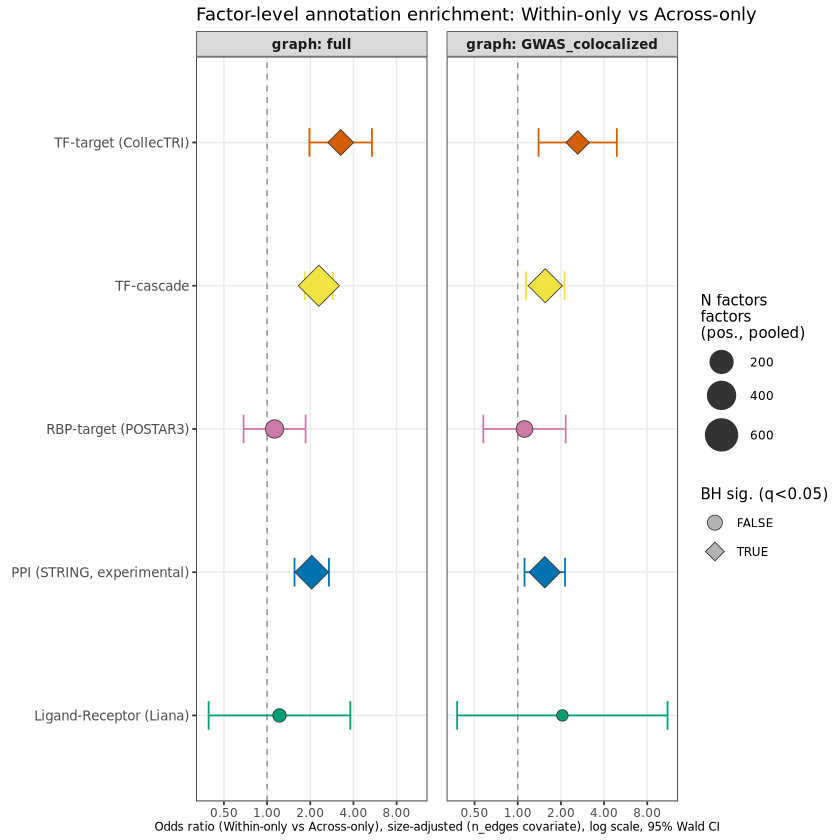

In [14]:
category_colors <- c(
  "TF-target (CollecTRI)"       = palettes$vibrant$vermillion,
  "RBP-target (POSTAR3)"        = palettes$vibrant$magenta,
  "Ligand-Receptor (Liana)"     = palettes$vibrant$green,
  "PPI (STRING, experimental)"  = palettes$vibrant$blue,
  "TF-cascade"                  = palettes$vibrant$yellow
)

plot_data <- logistic_results[, .(
  category_display = category_labels[category],
  graph_type = graph_type,
  or = or_group_adjusted, ci_low = or_ci_low, ci_high = or_ci_high,
  sig_BH_05
)]

plot_data <- merge(
  plot_data,
  fisher_results[, .(category, graph_type, n_pos = n_within_pos + n_across_pos)][
    , category_display := category_labels[category]],
  by.x = c("category_display", "graph_type"), by.y = c("category_display", "graph_type")
)

plot_data[, graph_type := factor(graph_type, levels = c("full", "GWAS_colocalized"))]

factor_forest_plot <- ggplot(plot_data, aes(x = or, y = category_display)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = ci_low, xmax = ci_high, color = category_display),
                orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE) +
  geom_point(aes(size = n_pos, fill = category_display, shape = sig_BH_05),
             color = "grey20", stroke = 0.35) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  scale_fill_manual(values = category_colors, name = "Category", guide = "none") +
  scale_color_manual(values = category_colors, guide = "none") +
  scale_size_continuous(name = "N factors\nfactors\n(pos., pooled)", range = c(3, 9)) +
  guides(shape = guide_legend(override.aes = list(size = 4, fill = "grey70"))) +
  scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16),
                labels = scales::label_number(accuracy = 0.01)) +
  facet_grid(
    cols = vars(graph_type),
    labeller = labeller(graph_type = as_labeller(function(x) paste("graph:", x)))
  ) +
  labs(
    x = "Odds ratio (Within-only vs Across-only), size-adjusted (n_edges covariate), log scale, 95% Wald CI",
    y = NULL,
    title = "Factor-level annotation enrichment: Within-only vs Across-only"
  ) +
  theme_bw(base_size = 9, base_family = "sans") +
  theme(
    axis.title.x = element_text(size = 7),
    axis.text.y  = element_text(size = 8),
    axis.ticks   = element_line(linewidth = 0.5),
    panel.border = element_rect(linewidth = 0.5, fill = NA),
    strip.text = element_text(size = 8, face = "bold"),
    panel.grid.minor = element_blank(),
    panel.spacing.x = unit(0.8, "lines")
  )

print(factor_forest_plot)

ggsave(paste0(outdir, "factor_ER_forest_plot.pdf"), factor_forest_plot, width = 260, height = 100, units = "mm")
ggsave(paste0(outdir, "factor_ER_forest_plot.png"), factor_forest_plot, width = 260, height = 100, units = "mm", dpi = 300, bg = "white")
ggsave(paste0(outdir, "factor_ER_forest_plot.svg"), factor_forest_plot, width = 260, height = 100, units = "mm")
